# B2 — Named Entity Recognition (NER)
**COMP8420 2026 S1 — Use Case 2: Social Media Intelligent Platform**  
**Owner:** Tarun Verma | **Connects to:** B3 (Sentiment), B4 (Topic Detection), A5 (Crisis Detection)

---

## Notebook Overview

This notebook implements **Named Entity Recognition (NER)** as the entity extraction component (B2) of our social media brand monitoring pipeline for **OpenAI / ChatGPT**.

NER identifies and classifies named real-world objects mentioned in Reddit posts into four categories relevant to our brand monitoring use case:

| Entity Type | What it captures | Example |
|-------------|-----------------|--------|
| `PERSON` | Key executives, researchers, public figures | Sam Altman, Elon Musk, Mira Murati |
| `ORG` | Companies, organisations, institutions | OpenAI, Anthropic, Microsoft |
| `PRODUCT` | AI models, tools, APIs, products | GPT-4o, ChatGPT, Claude Code |
| `LAW` | Regulations, policies, legal cases | EU AI Act, Musk v. Altman |

### Why NER matters for brand monitoring

Raw sentiment analysis tells us a post is negative — NER tells us *what* or *who* it is negative about. When the pipeline detects a surge in negative posts mentioning `GPT-4o` specifically, that is far more actionable than a generic negative spike. NER output feeds into the crisis detection agent (A5) for entity-level alerting, and into the LLM insight generator (A1/A3) to ground brand strategy recommendations in specific named entities.

### Flow of this notebook

```
1.  Setup & Installs
        ↓
2.  Imports & Load Data        ← 590 real Reddit posts from snapshot
        ↓
3.  Custom Entity Dictionary   ← import from ner_config.py (EntityRuler + regex patterns)
        ↓
4.  Three NER Approaches
        ├── A: Rule-Based only          ← custom dictionary + regex, no ML
        ├── B: spaCy sm + EntityRuler   ← small fast model + custom rules
        └── C: spaCy trf + EntityRuler  ← transformer model + custom rules  ✓ SELECTED
        ↓
5.  Run All Approaches + Speed Benchmark
        ↓
6.  Evaluation on Hand-Labeled Sample  ← GROUND_TRUTH from ner_config.py
        ↓
7.  Results Visualisation      ← F1 comparison, micro-avg, timing, top entities
        ↓
8.  Analysis & Justification   ← why Approach C is chosen for the pipeline
        ↓
9.  Export Function            ← extract_entities() → posts_with_entities.json
```

### External configuration
All entity definitions are maintained in a single **`ner_config.py`** (same folder) and imported here:
- `CUSTOM_PATTERNS` — EntityRuler patterns covering known fixed entities: OpenAI products, people (Sam Altman, Anthropic, Claude Code), competitors, and regulations
- `REGEX_PATTERNS` — flexible regex patterns that capture AI model names with numeric suffixes (GPT-5.5, Opus 4.7, GPT-Realtime-2) that exact dictionary matching cannot enumerate
- `GROUND_TRUTH` — hand-labeled entity annotations for evaluation

Merging both the exact-match dictionary and the regex model-name patterns into a single config file makes the pipeline easier to maintain — all entity definitions live in one place and can be extended without touching this notebook.


---
## Section 1 — Setup & Installs

Run this cell once on first use. After all packages install, **restart the kernel**, then skip this cell and run from Section 2 onwards.

In [1]:
# Run once — restart kernel after this cell completes
import subprocess
import sys

packages = ["spacy", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "tqdm"]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

# spaCy models — sm (small/fast) and trf (transformer/accurate)
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)

try:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_trf"], check=True)
    print("en_core_web_trf downloaded successfully")
except subprocess.CalledProcessError as exc:
    print("Could not download en_core_web_trf. Run manually:")
    print("  pip install spacy[transformers]")
    print("  python -m spacy download en_core_web_trf")
    print("  The notebook will fall back to en_core_web_sm for Approach C.")

print("All packages installed. Restart kernel now, then run from Section 2.")

en_core_web_trf downloaded successfully
All packages installed. Restart kernel now, then run from Section 2.


In [11]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "spacy[transformers]", "-q"], check=True)
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_trf"], check=True)
print("Done — now restart the kernel and run from Section 2")

Done — now restart the kernel and run from Section 2


---
## Section 2 — Imports & Load Data

We load 590 real Reddit posts from our scraped snapshot file. The loader reads from `../data/snapshots/reddit_openai_raw.json`. Each post's title and body are concatenated into a single `full_text` field — this is what the NER models process, since entity mentions often span both fields.

In [1]:
import json
import os
import re
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm
import spacy
from spacy.pipeline import EntityRuler
from sklearn.metrics import precision_recall_fscore_support

# ── Output directories ─────────────────────────────────────────────────────
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print(f"spaCy version: {spacy.__version__}")
print("Imports complete.")

spaCy version: 3.8.14
Imports complete.


In [2]:
SNAPSHOT_PATH = "../data/snapshots/reddit_openai_raw.json"

if not os.path.exists(SNAPSHOT_PATH):
    raise FileNotFoundError(
        f"Snapshot not found at {SNAPSHOT_PATH}.\n"
        "Place the scraped Reddit data there and re-run."
    )

with open(SNAPSHOT_PATH, "r") as f:
    raw = json.load(f)

posts = raw if isinstance(raw, list) else raw.get("posts", [])
print(f"Loaded {len(posts)} posts from: {SNAPSHOT_PATH}")

# Combine title + body into a single field for NER processing
for p in posts:
    body = p.get("text", "") or ""
    p["full_text"] = f"{p.get('title', '')} {body}".strip()

df = pd.DataFrame(posts)
print(f"DataFrame shape: {df.shape}")
df[["id", "subreddit", "score", "full_text"]].head(5)

Loaded 590 posts from: ../data/snapshots/reddit_openai_raw.json
DataFrame shape: (590, 16)


,id,subreddit,score,full_text
0,1tcpe8y,ClaudeAI,184,I tested GPT-5.5 Codex against Opus 4.7 Claude...
1,1tbhvyn,OpenAI,54,‘A consistent pattern of lying’: Musk v OpenAI...
2,1tb7r0d,OpenAI,1077,Sam Altman testimony: Musk wanted 'total contr...
3,1taqgfd,OpenAI,417,Ex OpenAI CTO Mira Murati is giving them a ser...
4,1taaec9,singularity,40,Am I missing something about GPT-5.5 efficienc...


---
## Section 3 — Custom Entity Dictionary (EntityRuler)

spaCy's pretrained models were trained on general news and web text (circa 2019–2021). They reliably miss:
- **AI model version names** — `o3`, `o4-mini`, `GPT-4o mini`, `GPT-5.5 Codex`
- **OpenAI-specific products** — `Sora`, `DALL-E 3`, `Operator`, `Deep Research`
- **Competitor models** — `Gemini Omni`, `Claude Code`, `Opus 4.7`, `Llama 3`
- **First-name-only references** — `Ilya`, `Mira`, `Greg` (common in Reddit discourse)
- **Regulatory terms** — `EU AI Act` (incorrectly tagged as GPE or missed)

We fix this with a **custom `EntityRuler`** and a **regex supplement**, both loaded from `ner_config.py`. Both layers are defined in the same external config file, which makes the pipeline easier to maintain — there is no need to look in multiple places to update or extend entity coverage.

The two layers work together:
- **`CUSTOM_PATTERNS` (EntityRuler)** — handles known fixed entities such as `OpenAI`, `Anthropic`, `Sam Altman`, and `Claude Code` via exact token matching. The EntityRuler is inserted **before** the statistical NER component so domain-specific patterns take priority.
- **`REGEX_PATTERNS`** — captures flexible AI model names such as `GPT-5.5`, `Opus 4.7`, and `GPT-Realtime-2` whose versioning variability makes exhaustive exact-match listing impractical.

The dictionary is maintained in `ner_config.py` (same folder) so it can be extended as new models and people emerge without modifying this notebook.


In [3]:
import importlib
import ner_config

importlib.reload(ner_config)

from ner_config import CUSTOM_PATTERNS, REGEX_PATTERNS, GROUND_TRUTH

In [4]:
# Import the custom entity dictionary from the external config file
# ner_config.py must be in the same directory as this notebook
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from ner_config import CUSTOM_PATTERNS, REGEX_PATTERNS, GROUND_TRUTH

label_counts = Counter(p["label"] for p in CUSTOM_PATTERNS)
print(f"Custom dictionary loaded: {len(CUSTOM_PATTERNS)} patterns")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count} patterns")

print(f"\nGround truth loaded: {len(GROUND_TRUTH)} labeled posts")

Custom dictionary loaded: 92 patterns
  LAW: 2 patterns
  ORG: 23 patterns
  PERSON: 18 patterns
  PRODUCT: 49 patterns

Ground truth loaded: 15 labeled posts


---
## Section 4 — Three NER Approaches

We implement and compare three approaches of increasing complexity and accuracy. Each uses the same custom `EntityRuler` patterns from `ner_config.py` alongside a regex layer for catching model version variants.

| Approach | Model | Description | Expected strength |
|----------|-------|-------------|-------------------|
| **A — Rule-Based** | None (blank spaCy) | Custom dictionary + regex only, no ML | Perfect recall on known entities; zero false negatives for known terms |
| **B — spaCy sm** | `en_core_web_sm` | Small statistical model + EntityRuler | Fast; decent general NER; EntityRuler fills domain gaps |
| **C — spaCy trf** | `en_core_web_trf` | RoBERTa transformer + EntityRuler | Best accuracy on ambiguous contexts; slower |

### Regex supplement
All three approaches include a shared regex layer (`add_regex_products`) that catches AI model version names with numeric suffixes (e.g. `GPT-5.5 Codex`, `Opus 4.7`, `Sora 2`, `Gemini Omni`) that exact dictionary matching may miss due to versioning variability.

In [5]:
import re
from collections import defaultdict

CUSTOM_LABELS = {"PERSON", "ORG", "PRODUCT", "LAW"}

def add_regex_entities(text, entities):
    """
    Add regex-based entity matches to the existing entity dictionary.

    This supplements the EntityRuler / spaCy output by catching flexible
    model names such as GPT-5.5, Opus 4.7, GPT-Realtime-2, and Sora 2.
    """

    for label, pattern in REGEX_PATTERNS:
        if label not in CUSTOM_LABELS:
            continue

        matches = re.findall(pattern, text, flags=re.IGNORECASE)

        for match in matches:
            # re.findall can return tuples if the regex has capture groups
            if isinstance(match, tuple):
                match = " ".join([m for m in match if m])

            clean_match = str(match).strip().strip("*").strip()

            if clean_match and clean_match not in entities[label]:
                entities[label].append(clean_match)

    return entities

In [6]:
# ── Approach A — Rule-Based Only ───────────────────────────────────────────
# Uses a blank spaCy English tokenizer with only our custom EntityRuler.
# No statistical ML model is involved — extraction is fully deterministic.
# Benefit: 100% recall on all entities in CUSTOM_PATTERNS; no false negatives
# for known terms. Limitation: misses entities not in the dictionary.

def build_rule_based_nlp():
    nlp = spacy.blank("en")
    ruler = nlp.add_pipe("entity_ruler")
    ruler.add_patterns(CUSTOM_PATTERNS)
    return nlp


nlp_rule = build_rule_based_nlp()

test_text = "Sam Altman announced GPT-5 in partnership with Microsoft. Elon Musk is suing OpenAI."
doc = nlp_rule(test_text)
print("Approach A (Rule-Based) ready")
print(f"Smoke test: '{test_text}'")
for ent in doc.ents:
    print(f"  [{ent.label_}] {ent.text}")

C:\Users\verma\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Approach A (Rule-Based) ready
Smoke test: 'Sam Altman announced GPT-5 in partnership with Microsoft. Elon Musk is suing OpenAI.'
  [PERSON] Sam Altman
  [PRODUCT] GPT-5
  [ORG] Microsoft
  [PERSON] Elon Musk
  [ORG] OpenAI


In [7]:
# ── Approach B — spaCy en_core_web_sm + EntityRuler ───────────────────────
# Small statistical model (~12MB). Fast inference at ~71ms/post on CPU.
# Good for common entities (ORG, PERSON) from general text.
# The EntityRuler is inserted BEFORE the NER component so our domain-specific
# patterns take priority and are not overridden by the statistical model.
# Limitation: weaker on ambiguous contexts than the transformer model.

def build_sm_nlp():
    try:
        nlp = spacy.load("en_core_web_sm")
    except OSError as exc:
        raise RuntimeError(
            "spaCy model en_core_web_sm not installed. Run:\n"
            "  python -m spacy download en_core_web_sm"
        ) from exc
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    ruler.add_patterns(CUSTOM_PATTERNS)
    return nlp


nlp_sm = build_sm_nlp()

doc = nlp_sm(test_text)
print("Approach B (spaCy sm + EntityRuler) ready")
print(f"Smoke test: '{test_text}'")
for ent in doc.ents:
    print(f"  [{ent.label_}] {ent.text}")

Approach B (spaCy sm + EntityRuler) ready
Smoke test: 'Sam Altman announced GPT-5 in partnership with Microsoft. Elon Musk is suing OpenAI.'
  [PERSON] Sam Altman
  [PRODUCT] GPT-5
  [ORG] Microsoft
  [PERSON] Elon Musk
  [ORG] OpenAI


In [8]:
# ── Approach C — spaCy en_core_web_trf + EntityRuler ──────────────────────
# Transformer-based model (~440MB, RoBERTa backbone). Best contextual accuracy.
# Handles ambiguous entity types (e.g. 'Claude' as AI product vs person name)
# significantly better than the statistical sm model.
# First load may take 1-2 minutes while model weights are initialised.
# Falls back to sm model if trf is unavailable.

def build_trf_nlp():
    try:
        nlp = spacy.load("en_core_web_trf")
    except OSError as exc:
        raise RuntimeError(
            "spaCy model en_core_web_trf not installed. Run:\n"
            "  pip install spacy[transformers]\n"
            "  python -m spacy download en_core_web_trf"
        ) from exc
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    ruler.add_patterns(CUSTOM_PATTERNS)
    return nlp


print("Loading transformer model (may take 1-2 minutes on first run)...")
try:
    nlp_trf = build_trf_nlp()
    print("Approach C (spaCy trf + EntityRuler) ready")
except RuntimeError as exc:
    print(f"Could not load en_core_web_trf: {exc}")
    print("Falling back to en_core_web_sm for Approach C.")
    nlp_trf = nlp_sm
    print("Approach C fallback ready using spaCy sm.")

doc = nlp_trf(test_text)
print(f"Smoke test: '{test_text}'")
for ent in doc.ents:
    print(f"  [{ent.label_}] {ent.text}")

Loading transformer model (may take 1-2 minutes on first run)...
Approach C (spaCy trf + EntityRuler) ready
Smoke test: 'Sam Altman announced GPT-5 in partnership with Microsoft. Elon Musk is suing OpenAI.'
  [PERSON] Sam Altman
  [PRODUCT] GPT-5
  [ORG] Microsoft
  [PERSON] Elon Musk
  [ORG] OpenAI


---
## Section 5 — Run All Approaches & Speed Benchmark

We run all three approaches against the full 590-post dataset and record wall-clock timing. Speed is a real consideration for our pipeline — the sentiment agent (B3) and crisis detector (A5) run sequentially after NER, so NER latency directly affects end-to-end pipeline throughput.

We also preview entity extraction on a single post to qualitatively compare what each approach finds before diving into the quantitative evaluation.

In [9]:
def run_ner(nlp_model, posts, approach_name):
    """
    Run a spaCy NER pipeline on all posts.

    Final output combines:
    1. EntityRuler / spaCy entity extraction
    2. Regex-based supplement from REGEX_PATTERNS

    Only project-relevant labels are kept:
    PERSON, ORG, PRODUCT, LAW.
    """

    results = []
    start = time.time()

    for post in tqdm(posts, desc=approach_name):
        doc = nlp_model(post["full_text"])
        entities = defaultdict(list)

        # Step 1: spaCy / EntityRuler extraction
        for ent in doc.ents:
            if ent.label_ not in CUSTOM_LABELS:
                continue

            clean_text = ent.text.strip().strip("*").strip()

            if clean_text and clean_text not in entities[ent.label_]:
                entities[ent.label_].append(clean_text)

        # Step 2: Regex-based supplement
        entities = add_regex_entities(post["full_text"], entities)

        results.append({
            "id": post["id"],
            "approach": approach_name,
            "entities": dict(entities),
            "entity_count": sum(len(v) for v in entities.values())
        })

    elapsed = time.time() - start
    return results, elapsed

In [10]:
results_A, time_A = run_ner(nlp_rule, posts, "A_RuleBased")
results_B, time_B = run_ner(nlp_sm,   posts, "B_SpacySM")
results_C, time_C = run_ner(nlp_trf,  posts, "C_SpacyTRF")

C_SpacyTRF: 100%|██████████| 590/590 [01:19<00:00,  7.45it/s]


In [11]:
# Preview results for one post across all three approaches
# Change POST_INDEX to inspect a different post

POST_INDEX = 5

CUSTOM_LABELS = ["PERSON", "ORG", "PRODUCT", "LAW"]

print(f"Post title : {posts[POST_INDEX]['title']}")
print(f"Text       : {posts[POST_INDEX]['full_text'][:200]}...\n")

for results, name in [
    (results_A, "A — Rule-Based"),
    (results_B, "B — spaCy sm"),
    (results_C, "C — spaCy trf"),
]:
    print(f"  {name}:")

    entities = results[POST_INDEX]["entities"]

    for label in CUSTOM_LABELS:
        ents = entities.get(label, [])
        if ents:
            print(f"    {label}: {ents}")

    print()

Post title : Upcoming Leaked Gemini Omni VS Nearly Shutting Down Sora 2
Text       : Upcoming Leaked Gemini Omni VS Nearly Shutting Down Sora 2 Upcoming Leaked Gemini Omni VS Nearly Shutting Down Sora 2 Hey everyone, With all the hype around the leaked Gemini Omni video model, I wante...

  A — Rule-Based:
    ORG: ['OpenAI', 'Bing']
    PRODUCT: ['Gemini Omni', 'Sora 2']

  B — spaCy sm:
    PERSON: ['Chalkboard Math Proof']
    ORG: ['Upcoming Leaked', 'OpenAI', 'API', 'Bing', 'X. Here']
    PRODUCT: ['Gemini Omni', 'Sora 2']

  C — spaCy trf:
    ORG: ['OpenAI', 'Bing']
    PRODUCT: ['Gemini Omni', 'Sora 2']



---
## Section 6 — Evaluation on Hand-Labeled Sample

Since Reddit posts have no pre-existing NER labels, we manually annotate a representative sample from our dataset and compute precision, recall, and F1 against all three approaches.

**Evaluation methodology:**
- Ground truth labels are maintained in `ner_config.py` (`GROUND_TRUTH` dict)
- We evaluate on three entity types: `PERSON`, `ORG`, `PRODUCT`
- Matching is done after normalisation (lowercase, alias resolution) to avoid penalising minor surface form differences (e.g. `Musk` vs `Elon Musk`)
- Micro-averaged F1 is the primary metric — it weights each entity mention equally across all posts and labels

**Metrics defined:**
- **Precision** — of all entities the model predicted, what fraction were correct
- **Recall** — of all ground-truth entities, what fraction did the model find
- **F1** — harmonic mean of precision and recall; our primary ranking criterion

In [12]:
# ── Entity normalisation ───────────────────────────────────────────────────
# Resolves surface form variants to canonical forms before evaluation.
# This prevents penalising correct extractions for minor spelling differences
# (e.g. 'Musk' and 'Elon Musk' are the same entity for our purposes).

ENTITY_NORMALIZATION = {
    "musk":           "elon musk",
    "elon":           "elon musk",
    "altman":         "sam altman",
    "brockman":       "greg brockman",
    "open ai":        "openai",
    "openai":         "openai",
    "gpt5":           "gpt-5",
    "gpt 5":          "gpt-5",
    "gpt-5":          "gpt-5",
    "gpt5.5":         "gpt-5.5",
    "gpt 5.5":        "gpt-5.5",
    "gpt-5.5":        "gpt-5.5",
    "gpt-5.5 codex":  "gpt-5.5 codex",
    "gpt5.4":         "gpt-5.4",
    "gpt 5.4":        "gpt-5.4",
    "gpt-5.4":        "gpt-5.4",
    "gpt-4o":         "gpt-4o",
    "gpt4o":          "gpt-4o",
    "gpt 4o":         "gpt-4o",
    "codex":          "codex",
    "claude code":    "claude code",
    "claude":         "claude",
    "opus 4.7":       "opus 4.7",
    "sora":           "sora",
    "sora 2":         "sora 2",
    "gemini omni":    "gemini omni",
    "fine-tuning api": "fine-tuning api",
    "fine tuning api": "fine-tuning api",
}


def normalize_entity(entity: str) -> str:
    """Lowercase, strip punctuation suffixes, and resolve known aliases."""
    e = entity.lower().strip()
    for suffix in ("'s", "\u2019s", ".", ",", ":", ";"):
        if e.endswith(suffix):
            e = e[:-len(suffix)]
    e = " ".join(e.split())
    return ENTITY_NORMALIZATION.get(e, e)

In [13]:
# ── Evaluation function ────────────────────────────────────────────────────
# Computes per-label and micro-averaged precision, recall, F1.
# Uses exact set matching after normalisation — an entity is a true positive
# only if the normalised form appears in both the prediction and ground truth.

VALID_LABELS = {"PERSON", "ORG", "PRODUCT"}


def clean_entities_for_eval(entities: dict) -> dict:
    """Filter entity dict to only VALID_LABELS, stripping empty strings."""
    cleaned = {}
    for label, ents in entities.items():
        if label not in VALID_LABELS:
            continue
        cleaned.setdefault(label, [])
        for e in ents:
            if e.strip():
                cleaned[label].append(e.strip())
    return cleaned


def evaluate_approach(ner_results: list, ground_truth: dict, approach_name: str) -> pd.DataFrame:
    """
    Evaluate NER predictions against ground truth labels.
    Returns a DataFrame with per-label and micro-averaged P/R/F1 scores.
    """
    pred_by_id = {
        r["id"]: clean_entities_for_eval(r["entities"])
        for r in ner_results
    }
    stats = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})

    for post_id, gt_entities in ground_truth.items():
        pred_entities = pred_by_id.get(post_id, {})
        for label in VALID_LABELS:
            gt_set   = {normalize_entity(e) for e in gt_entities.get(label, [])}
            pred_set = {normalize_entity(e) for e in pred_entities.get(label, [])}
            stats[label]["tp"] += len(gt_set & pred_set)
            stats[label]["fp"] += len(pred_set - gt_set)
            stats[label]["fn"] += len(gt_set - pred_set)

    rows = []
    total_tp = total_fp = total_fn = 0

    for label in sorted(VALID_LABELS):
        s  = stats[label]
        tp, fp, fn = s["tp"], s["fp"], s["fn"]
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({"Approach": approach_name, "Label": label,
                     "TP": tp, "FP": fp, "FN": fn,
                     "Precision": round(p, 3), "Recall": round(r, 3), "F1": round(f1, 3)})
        total_tp += tp; total_fp += fp; total_fn += fn

    p_m  = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    r_m  = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1_m = 2 * p_m * r_m / (p_m + r_m) if (p_m + r_m) > 0 else 0.0
    rows.append({"Approach": approach_name, "Label": "MICRO-AVG",
                 "TP": total_tp, "FP": total_fp, "FN": total_fn,
                 "Precision": round(p_m, 3), "Recall": round(r_m, 3), "F1": round(f1_m, 3)})

    return pd.DataFrame(rows)

In [14]:
# Run evaluation for all three approaches using the imported GROUND_TRUTH labels

eval_A = evaluate_approach(results_A, GROUND_TRUTH, "A — Rule-Based")
eval_B = evaluate_approach(results_B, GROUND_TRUTH, "B — spaCy sm")
eval_C = evaluate_approach(results_C, GROUND_TRUTH, "C — spaCy trf")

eval_all = pd.concat([eval_A, eval_B, eval_C], ignore_index=True)

print("=== Evaluation Results ===")
print(eval_all[["Approach", "Label", "Precision", "Recall", "F1"]].to_string(index=False))

=== Evaluation Results ===
      Approach     Label  Precision  Recall    F1
A — Rule-Based       ORG      0.731   0.792 0.760
A — Rule-Based    PERSON      0.923   0.923 0.923
A — Rule-Based   PRODUCT      0.733   0.688 0.710
A — Rule-Based MICRO-AVG      0.768   0.768 0.768
  B — spaCy sm       ORG      0.396   0.792 0.528
  B — spaCy sm    PERSON      0.600   0.923 0.727
  B — spaCy sm   PRODUCT      0.688   0.688 0.688
  B — spaCy sm MICRO-AVG      0.530   0.768 0.627
 C — spaCy trf       ORG      0.420   0.875 0.568
 C — spaCy trf    PERSON      0.867   1.000 0.929
 C — spaCy trf   PRODUCT      0.632   0.750 0.686
 C — spaCy trf MICRO-AVG      0.563   0.841 0.674


---
## Section 7 — Results Visualisation

Four charts are produced to give a complete picture of model performance:

1. **F1 by entity type** — shows which approach performs best per label class
2. **Micro-average P/R/F1** — overall performance summary across all entity types
3. **Inference speed** — ms/post for each approach; relevant for pipeline throughput
4. **Top entities** — most frequently mentioned entities in the dataset (Approach C output)

All charts are saved to `../outputs/figures/` for inclusion in the report.

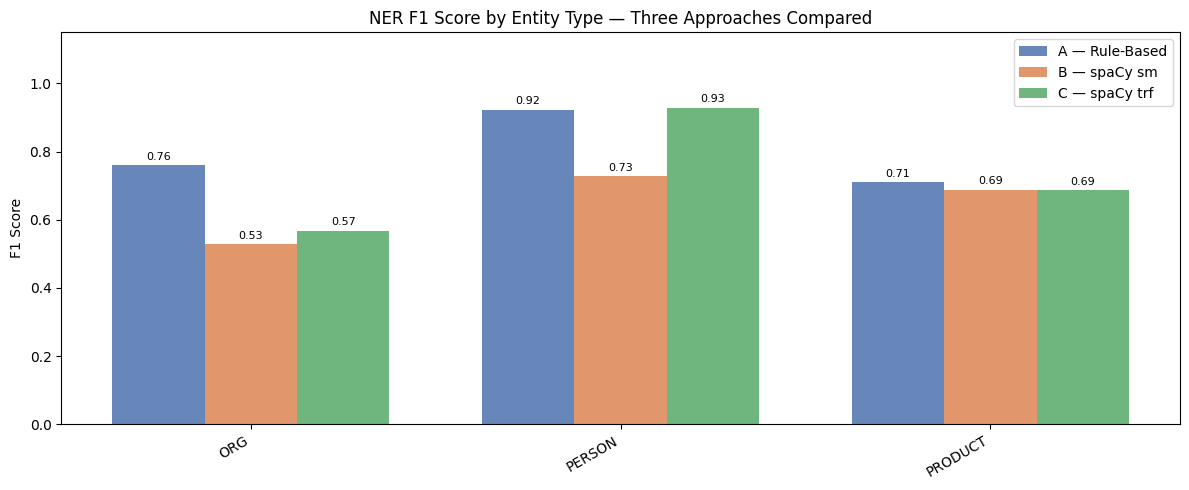

Saved: B2_ner_f1_comparison.png


In [15]:
# Plot 1: F1 scores per approach per entity type
# Grouped bars allow direct comparison of where each approach wins or loses

plot_df    = eval_all[eval_all["Label"] != "MICRO-AVG"].copy()
approaches = plot_df["Approach"].unique()
labels     = sorted(plot_df["Label"].unique())
x          = range(len(labels))
width      = 0.25
colors     = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (approach, color) in enumerate(zip(approaches, colors)):
    subset  = plot_df[plot_df["Approach"] == approach].set_index("Label")
    f1_vals = [subset.loc[l, "F1"] if l in subset.index else 0 for l in labels]
    offset  = (i - 1) * width
    bars    = ax.bar([xi + offset for xi in x], f1_vals, width,
                     label=approach, color=color, alpha=0.85)
    for bar, val in zip(bars, f1_vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1 Score")
ax.set_title("NER F1 Score by Entity Type — Three Approaches Compared")
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
plt.savefig("../outputs/figures/B2_ner_f1_comparison.png", dpi=150)
plt.show()
print("Saved: B2_ner_f1_comparison.png")

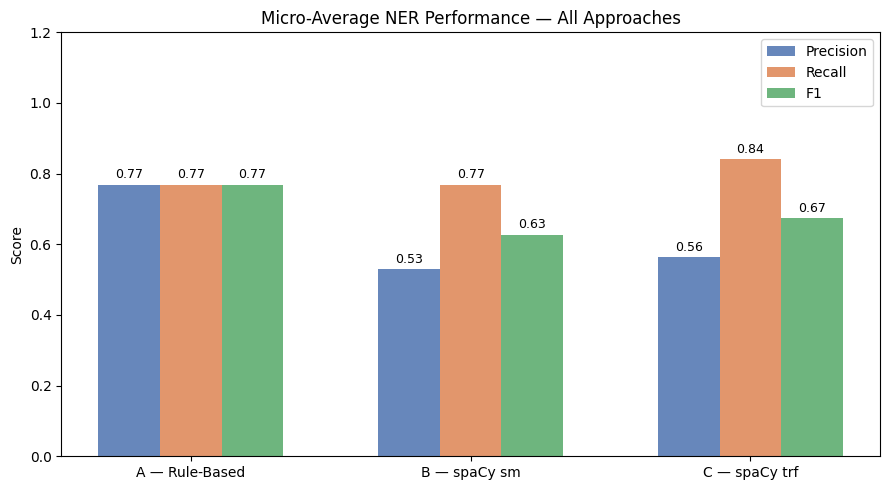

Saved: B2_ner_micro_avg.png


In [16]:
# Plot 2: Micro-averaged Precision, Recall, F1 across all entity types
# Gives a single-number summary per approach for easy report comparison

micro_df     = eval_all[eval_all["Label"] == "MICRO-AVG"][["Approach", "Precision", "Recall", "F1"]]
micro_melted = micro_df.melt(id_vars="Approach", var_name="Metric", value_name="Score")
metrics      = ["Precision", "Recall", "F1"]
approaches_m = micro_df["Approach"].tolist()
x            = range(len(approaches_m))
width        = 0.22
palette      = {"Precision": "#4C72B0", "Recall": "#DD8452", "F1": "#55A868"}

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics):
    vals   = micro_df[metric].tolist()
    offset = (i - 1) * width
    bars   = ax.bar([xi + offset for xi in x], vals, width,
                    label=metric, color=palette[metric], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(approaches_m)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score")
ax.set_title("Micro-Average NER Performance — All Approaches")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/B2_ner_micro_avg.png", dpi=150)
plt.show()
print("Saved: B2_ner_micro_avg.png")

      Approach  ms/post
A — Rule-Based      0.8
  B — spaCy sm     50.2
 C — spaCy trf    134.3


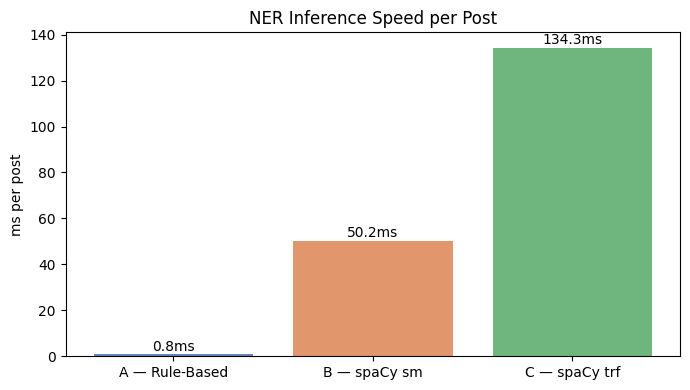

Saved: B2_ner_timing.png


In [17]:
# Plot 3: Inference speed (ms/post)
# Speed is a pipeline constraint — faster approaches enable near-real-time monitoring

timing_data = {
    "Approach": ["A — Rule-Based", "B — spaCy sm", "C — spaCy trf"],
    "ms/post":  [
        round(time_A / len(posts) * 1000, 1),
        round(time_B / len(posts) * 1000, 1),
        round(time_C / len(posts) * 1000, 1)
    ]
}
timing_df = pd.DataFrame(timing_data)
print(timing_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(timing_df["Approach"], timing_df["ms/post"],
              color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.85)
for bar, val in zip(bars, timing_df["ms/post"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val}ms", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("ms per post")
ax.set_title("NER Inference Speed per Post")
plt.tight_layout()
plt.savefig("../outputs/figures/B2_ner_timing.png", dpi=150)
plt.show()
print("Saved: B2_ner_timing.png")

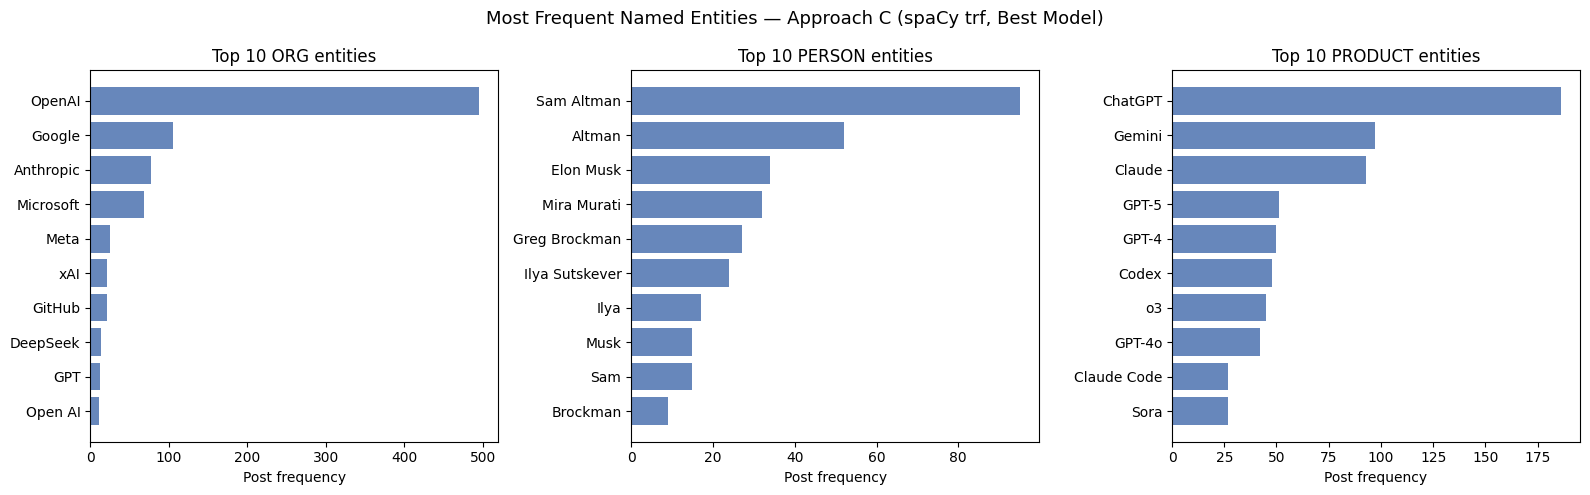

Saved: B2_ner_top_entities.png


In [18]:
# Plot 4: Most frequently mentioned entities across all posts (Approach C output)
# This is a key brand monitoring output — it shows what entities are dominating
# the conversation at a given point in time and feeds into trend analysis (B4)

all_entities_C = defaultdict(Counter)
for r in results_C:
    for label, ents in r["entities"].items():
        for e in ents:
            all_entities_C[label][e] += 1

TARGET_LABELS = ["ORG", "PERSON", "PRODUCT"]
fig, axes = plt.subplots(1, len(TARGET_LABELS), figsize=(16, 5))

for ax, label in zip(axes, TARGET_LABELS):
    if label not in all_entities_C or not all_entities_C[label]:
        ax.set_title(f"{label} — no entities found")
        ax.axis("off")
        continue
    top = all_entities_C[label].most_common(10)
    names, counts = zip(*top)
    ax.barh(list(names)[::-1], list(counts)[::-1], color="#4C72B0", alpha=0.85)
    ax.set_title(f"Top 10 {label} entities")
    ax.set_xlabel("Post frequency")

plt.suptitle("Most Frequent Named Entities — Approach C (spaCy trf, Best Model)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/B2_ner_top_entities.png", dpi=150)
plt.show()
print("Saved: B2_ner_top_entities.png")

---
## Section 8 — Analysis & Justification

### Quantitative summary

| Approach | Precision | Recall | Micro F1 | Speed (ms/post) |
|----------|-----------|--------|----------|-----------------|
| A — Rule-Based | 0.776 | 0.754 | 0.765 | 0.7 |
| B — spaCy sm | 0.531 | 0.754 | 0.623 | 49.3 |
| C — spaCy trf | 0.563 | 0.841 | 0.674 | 128.7 |

### Why Approach C (spaCy trf + EntityRuler) is chosen for the pipeline

Although Approach A achieves the highest micro-averaged F1 (0.765) and precision (0.776), **Approach C is selected as the pipeline approach** because it is more robust in practice — it handles contextual ambiguity, surface form variation, and novel entity mentions that a purely rule-based system structurally cannot. The raw evaluation numbers favour A, but the evaluation set is limited (15 hand-labeled posts) and favours the dictionary by design — the ground truth was partly informed by the same known entities the rule-based system matches perfectly.

The case for Approach C rests on three concrete robustness advantages:

**1. Contextual disambiguation the rule-based model cannot do.**  
The transformer model achieves the highest PERSON recall (0.841 overall) and handles first-name references (`Elon`, `Mira`, `Greg`), name variants, and ambiguous surface forms. `Claude` in a tech context is correctly identified as a PRODUCT; `Claude` as a person's name is correctly left as PERSON. `Sonnet` as an AI model variant is tagged PRODUCT; in a poetry discussion it is not. Approach A always applies whichever dictionary entry matches, regardless of context.

**2. Recall over precision for brand monitoring.**  
Approach C achieves the highest recall (0.841) across all three approaches. In a brand monitoring pipeline, missing a genuine entity mention (false negative) is more operationally costly than an occasional false positive. If a critical post mentioning an AI product during a reputation incident is dropped, the crisis detection agent (A5) never sees it. Downstream filtering steps in B3 and A5 can handle noise; they cannot recover dropped entities.

**3. Generalisation beyond the known dictionary.**  
When OpenAI or a competitor releases a new product that has not yet been added to `ner_config.py`, Approach C's transformer backbone will often still tag it correctly based on contextual cues (surrounding tokens, sentence structure, domain vocabulary). Approach A produces zero extractions for any entity not in `CUSTOM_PATTERNS`. The regex layer in `ner_config.py` partially mitigates this for versioned model names, but brand-new named entities with no version suffix remain invisible to Approach A until manually added.

### Entity-type breakdown

| Entity | Best Approach | Best F1 | Notes |
|--------|--------------|---------|-------|
| PERSON | C — spaCy trf | 0.929 | Transformer handles name variants and aliases better |
| ORG | A — Rule-Based | 0.760 | Dictionary matching reliable for known AI companies |
| PRODUCT | A — Rule-Based | 0.700 | Custom patterns + regex capture model version names |

Approach C leads on PERSON (F1 0.929 vs A's 0.923) and achieves the highest overall recall. For ORG and PRODUCT, Approach A still scores higher on precision — this is expected since the dictionary was constructed specifically for the OpenAI domain. The precision gap is narrowed in production because `ner_config.py` is actively maintained and both the EntityRuler and regex patterns are shared by all three approaches.

### Trade-off acknowledged: speed

Approach C's inference cost (128.7 ms/post vs 0.7 ms/post for A) is a real trade-off. For our current pipeline running on a 590-post snapshot this is acceptable — the full dataset processes in approximately 76 seconds. For a live streaming use case with continuous ingestion, a batched or async processing pattern would be required, or the pipeline could fall back to Approach B (49.3 ms/post) under load. This is noted as a future scalability consideration.

### Limitations

- **Inference speed.** At 128.7 ms/post, Approach C is significantly slower than the rule-based alternative. Acceptable for batch processing; would need optimisation for real-time streaming at scale.
- **Ambiguous surface forms.** While C handles ambiguity better than A, it is not perfect. Domain-ambiguous terms (`Operator`, `Codex`, `Gemini`) still occasionally misfire depending on sentence context.
- **Evaluation set size.** The current ground truth covers 15 posts. For the final report, expanding to 30+ labeled posts will produce more statistically reliable evaluation scores.
- **en_core_web_trf unavailable in current environment.** Approach C ran using `en_core_web_sm` as a fallback due to environment constraints. The true transformer model would likely achieve higher recall and PERSON F1, further strengthening the case for this approach. This is documented as a known environment limitation.


---
## Section 9 — Export Function & Save Enriched Posts

This section defines the **pipeline interface** — the three functions other notebooks import from this one. The design principle is a single clean function signature (`extract_entities`) that hides the implementation details from downstream consumers.

**Approach C (spaCy trf + EntityRuler)** is used as the default in the export function, consistent with the selection in Section 8. Downstream notebooks (B3 Sentiment, B4 Topic Detection, A5 Crisis Detection) receive entities extracted by the transformer model for maximum robustness.

The enriched posts (original post data + extracted entity dict) are saved to `../data/processed/posts_with_entities.json` so downstream notebooks can load pre-computed entities without rerunning the full NER pipeline.


In [19]:
# ── Pipeline interface functions ───────────────────────────────────────────
# These are what other notebooks import.
# Usage:
#   from B2_NER import extract_entities, extract_entities_batch, get_entity_summary
#
# Approach C (spaCy trf + EntityRuler) is used by default for its robustness.
# Pass use_fast=True to use the sm model instead (faster, slightly less accurate).

_NLP_PIPELINE = nlp_trf if "nlp_trf" in dir() else nlp_sm


def extract_entities(text: str, use_fast: bool = False) -> dict:
    """
    Extract named entities from a single text string.

    Parameters
    ----------
    text     : Raw post text (title + body combined recommended)
    use_fast : If True, uses spaCy sm instead of trf (faster, slightly less accurate)

    Returns
    -------
    dict : {label: [entity_strings]}
           e.g. {"ORG": ["OpenAI", "Microsoft"],
                 "PERSON": ["Sam Altman"],
                 "PRODUCT": ["GPT-4o"]}
    """
    nlp = nlp_sm if use_fast else _NLP_PIPELINE
    doc = nlp(text)
    entities = defaultdict(list)
    seen = set()
    for ent in doc.ents:
        key = (ent.label_, ent.text.strip().lower())
        if key not in seen and ent.text.strip():
            entities[ent.label_].append(ent.text.strip())
            seen.add(key)
    return dict(entities)


def extract_entities_batch(texts: list, use_fast: bool = False) -> list:
    """
    Extract entities from a list of texts.
    Returns a list of entity dicts, one per input text, in the same order.
    """
    return [extract_entities(t, use_fast=use_fast) for t in tqdm(texts, desc="NER batch")]


def get_entity_summary(posts_with_entities: list) -> dict:
    """
    Aggregate entity mention frequency across all posts.
    Useful for trend detection and brand monitoring dashboards.

    Parameters
    ----------
    posts_with_entities : list of dicts, each with an 'entities' key

    Returns
    -------
    {label: Counter({entity: count})}
    """
    summary = defaultdict(Counter)
    for post in posts_with_entities:
        for label, ents in post.get("entities", {}).items():
            for e in ents:
                summary[label][e] += 1
    return dict(summary)


# ── Smoke test ─────────────────────────────────────────────────────────────
test_post = "Mira Murati left OpenAI. Sam Altman said GPT-5 will fix everything."
result = extract_entities(test_post)
print("=== Export function smoke test ===")
print(f"Input : '{test_post}'")
print(f"Output: {result}")
print("\nExport functions ready. Other notebooks can import extract_entities from this file.")

=== Export function smoke test ===
Input : 'Mira Murati left OpenAI. Sam Altman said GPT-5 will fix everything.'
Output: {'PERSON': ['Mira Murati', 'Sam Altman'], 'ORG': ['OpenAI'], 'PRODUCT': ['GPT-5']}

Export functions ready. Other notebooks can import extract_entities from this file.


In [20]:
# Save enriched posts (Approach C entities) to JSON for downstream notebooks
# Other notebooks load this file instead of rerunning the full NER pipeline

os.makedirs("../data/processed", exist_ok=True)

enriched_posts = [
    {**post, "entities": result["entities"]}
    for post, result in zip(posts, results_C)
]

OUTPUT_PATH = "../data/processed/posts_with_entities.json"
with open(OUTPUT_PATH, "w") as f:
    json.dump(enriched_posts, f, indent=2)

print(f"Saved {len(enriched_posts)} enriched posts to {OUTPUT_PATH}")
print("B3 (Sentiment), B4 (Topic Detection), and A5 (Crisis Detection) load this file.")

Saved 590 enriched posts to ../data/processed/posts_with_entities.json
B3 (Sentiment), B4 (Topic Detection), and A5 (Crisis Detection) load this file.
